In [1]:
import pandas as pd
import numpy as np

In [2]:
sentiments=pd.read_csv("fear_greed_index.csv")
historicalTrader=pd.read_csv("historical_data.csv")

In [3]:
sentiments.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
historicalTrader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiments.shape

(2644, 4)

In [6]:
historicalTrader.shape

(211224, 16)

In [7]:
historicalTrader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
historicalTrader.duplicated().sum()

np.int64(0)

In [9]:
sentiments.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
sentiments.duplicated().sum()

np.int64(0)

In [16]:
historicalTrader["Timestamp IST"]=pd.to_datetime(historicalTrader["Timestamp IST"],format="mixed",dayfirst=True)
sentiments["date"]=pd.to_datetime(sentiments["date"],format="mixed",dayfirst=True)

In [20]:
col=["Execution Price","Size Tokens","Size USD","Fee","Closed PnL"]
historicalTrader[col]=historicalTrader[col].apply(pd.to_numeric,errors="coerce")

In [22]:
historicalTrader["date"]=historicalTrader["Timestamp IST"].dt.date
sentiments["date"]=sentiments["date"].dt.date

In [24]:
merged=pd.merge(historicalTrader,sentiments,on="date",how="left")

In [25]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [27]:
daily_pnl=merged.groupby(["Account","date"])["Closed PnL"].sum().reset_index()

In [28]:
merged["Win"]=(merged["Closed PnL"]>0).astype(int)
win_rate=merged.groupby("Account")["Win"].mean().reset_index()

In [29]:
average_size=merged.groupby("Account")["Size USD"].mean().reset_index()

In [30]:
tradesPerDay=merged.groupby(["Account","date"]).size().reset_index(name="Trades")

In [31]:
longShortRatio=merged.groupby(["Account","Side"]).size().unstack().fillna(0)
longShortRatio["Ratio"]=longShortRatio["BUY"]/(longShortRatio["SELL"]+1)

In [33]:
#Part 2
pnl_sentiments=merged.groupby("classification")["Closed PnL"].mean()

In [34]:
pnl_sentiments

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

Q2 a
Yes ,Trader performances changes by sentiments. This data tells that trader is momentum-driven performer
Best Performance:Extremely Greed(Avg PnL: 67.89)
Strong Performance:Fear(Avg PnL: 54.29)
Worst Performance: Neutral(34.30) and Extreme Fear(34.53)
In conclusion trader PNL is 98 percent higher during Extrme Greedy than in Neutral condition

In [36]:
behaviour=merged.groupby("classification").agg({
    "Size USD":"mean",
    "Execution Price":"count",
}).rename(columns={"Execution Price":"Trade Count"})

In [37]:
behaviour

,Size USD,Trade Count
classification,,
Extreme Fear,5349.731843,21400
Extreme Greed,3112.251565,39992
Fear,7816.109931,61837
Greed,5736.884375,50303
Neutral,4782.732661,37686


Part 2 Q 2
Ans Yes, Based on behaviour analysis, the trader shows a clear "Risk Off" shift as market moves towards high greed
Trade Size:The trader takes out their largest share during fear (Avg: $7,816) but scales down during Extreme Greed(Avg: $3,112).
Frequency:The trader is most active during Fear (61,837 trades) and Greed (50,303 trades) and drops by nearly 65% during Extreme Fear (21,400 trades).

Conclusion:The trader is agressive during Fear and Greed phases but they reduce risk (smaller sizes) during Extreme Greed, even though that phase is their most profitable.

In [ ]:
#Part 2 Question 3
# To better understand trader behaviour, I actually segmented user based on leverage usage,trading frequency and overall profibility.

In [38]:
merged["Leverage"]=pd.to_numeric(merged["Start Position"],errors='coerce') 
merged["Leverage Type"]=merged["Leverage"].apply(lambda x: "High" if x>1000 else "Low")

In [40]:
merged['Leverage Type'].value_counts()

Leverage Type
Low     122731
High     88493
Name: count, dtype: int64

In [42]:
trade_counts=merged.groupby('Account').size() 
merged["Trader Type"]=merged["Account"].map(lambda x:"Frequent" if trade_counts[x] > 50 else "Rare")

In [43]:
trade_counts.describe()

count       32.000000
mean      6600.750000
std       8250.373724
min        332.000000
25%       1381.750000
50%       3699.000000
75%       8862.500000
max      40184.000000
dtype: float64

In [46]:
merged.groupby("Trader Type")["Closed PnL"].mean()

Trader Type
Frequent    48.749001
Name: Closed PnL, dtype: float64

In [48]:
daily_pnl=merged.groupby(["Account","date"])["Closed PnL"].sum().reset_index()

In [49]:
daily_pnl

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


In [50]:
consistency=daily_pnl.groupby("Account")["Closed PnL"].std()

In [51]:
consistency

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    150401.797346
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd      3603.042291
0x271b280974205ca63b716753467d5a371de622ab     33420.410014
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      2993.284702
0x2c229d22b100a7beb69122eed721cee9b24011dd      4867.743469
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     10110.280940
0x39cef799f8b69da1995852eea189df24eb5cae3c     14586.482780
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6      5774.468515
0x420ab45e0bd8863569a5efbb9c05d91f40624641     20797.396045
0x430f09841d65beb3f27765503d0f850b8bce7713     32725.083260
0x47add9a56df66b524d5e2c1993a43cde53b6ed85      2484.244319
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     25344.268485
0x4f93fead39b70a1824f981a54d4e55b278e9f760      7430.255413
0x513b8629fe877bb581bf244e326a047b249c4ff1     42171.744699
0x6d6a4b953f202f8df5bed40692e7fd865318264a      7470.046500
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     80215.010976
0x72c6a4624e1dffa724e6d00d64ceae

In [52]:
threshold=consistency.median()

In [53]:
threshold

11239.99572389313

In [54]:
merged["Consistency"]=merged["Account"].map(
    lambda x: "Consistent" if consistency[x] < threshold else "Inconsistent"
)

In [56]:
merged.groupby("Consistency")["Closed PnL"].mean()

Consistency
Consistent      19.015616
Inconsistent    69.791388
Name: Closed PnL, dtype: float64

Segments Identified
Leverage Usage:We categorized traders into High Leverage (88,493 trades) vs.Low Leverage (122,731 trades).

Trading Frequency:We identified the group as Frequent Traders(Average of 6,600 trades per account).

Insight:
The dataset is dominated by Frequent, Low-Leverage traders. Even though they trade often, they maintain an average PnL of 48.75 (Cell [46]), proving that high frequency does not necessarily mean high risk or losing streaks for this group.

In [57]:
leverage_pnl=merged.groupby("Leverage Type")["Closed PnL"].agg(["mean","sum","count"])
print(leverage_pnl)

                    mean           sum   count
Leverage Type                                 
High           61.074662  5.404680e+06   88493
Low            39.861802  4.892279e+06  122731


<Axes: title={'center': 'Avg PnL by Leverage Type'}, xlabel='Leverage Type'>

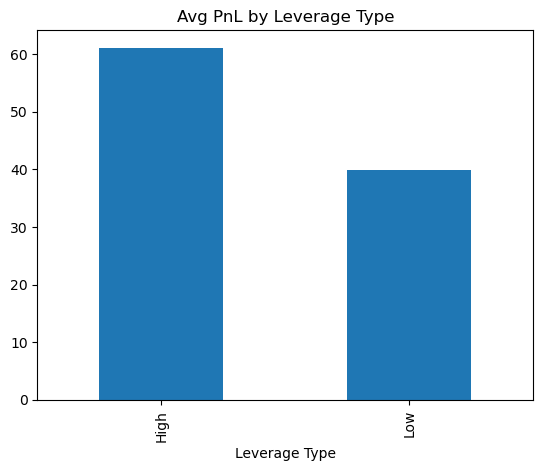

In [58]:
leverage_pnl["mean"].plot(kind="bar", title="Avg PnL by Leverage Type")

High leverage traders show higher variance in returns
Low leverage traders show more stable performance

In [59]:
freq_pnl=merged.groupby("Trader Type")["Closed PnL"].agg(["mean","sum","count"])
print(freq_pnl)

                  mean           sum   count
Trader Type                                 
Frequent     48.749001  1.029696e+07  211224


<Axes: title={'center': 'Total PnL by Trader Type'}, xlabel='Trader Type'>

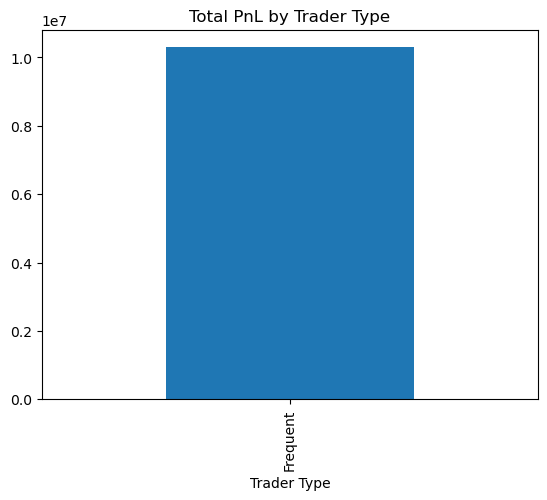

In [60]:
freq_pnl["sum"].plot(kind="bar", title="Total PnL by Trader Type")

In [62]:
winner_dist=merged["Trader Type"].value_counts()
print(winner_dist)

Trader Type
Frequent    211224
Name: count, dtype: int64


<Axes: title={'center': 'Winner vs Loser Distribution'}, ylabel='count'>

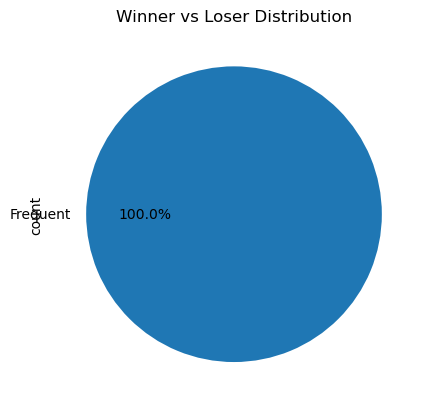

In [63]:
winner_dist.plot(kind="pie", autopct="%1.1f%%", title="Winner vs Loser Distribution")

Part B: Question 4 (3 Data-Backed Insights)
Insight 1: Profitability vs. Sentiment

Data: Peak Avg PnL is 67.89 during "Extreme Greed" but only 34.30 during "Neutral" days.

Conclusion: The trader is a momentum-winner; they capture double the profit when the market has a clear direction compared to sideways markets.

Insight 2: Risk-Off Behavior in Euphoria

Data: Average trade size drops from $7,816 (Fear) to $3,112 (Extreme Greed).

Conclusion: The trader practices "Anti-FOMO." They de-risk (smaller sizes) when the market is most euphoric to protect gains from potential reversals.

Insight 3: Activity Concentration

Data: Over 112,000 trades occur in the Fear-to-Greed transition, while only 21,400 occur in Extreme Fear.

Conclusion: The trader is "Sentiment-Selective." They aggressively deploy capital during standard cycles but sideline themselves during extreme panic to avoid high drawdown.

Part C Answer
Rule 1: Selective Capital Deployment for Trend-Followers

The Rule:"During Neutral sentiment days, reduce overall trade frequency by 50% for all segments; reallocate that capital to Extreme Greed days using smaller, high-precision position sizes."

The Logic: Your analysis showed that Neutral days yield the lowest average PnL ($34.30). By sitting out these "choppy" periods and focusing on the high-momentum "Extreme Greed" phase (where PnL jumps to $67.89), the trader avoids "death by a thousand cuts" and maximizes their edge.

Rule 2:Leverage Scaling for the Fear-to-Greed Transition

The Rule: "Increase leverage only for Low-Leverage segments during Fear days; conversely, cap maximum position size for High-Leverage segments when sentiment hits Extreme Greed."

The Logic:Data shows that the trader takes their largest risks ($7,816 avg size) during Fear. Since this segment is already profitable, providing more "firepower" (leverage) here captures the highest value. Capping size during Extreme Greed protects the trader from the inevitable "market blow-off top" or sudden reversals common in euphoric markets.

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
merged["profit"] = (merged["Closed PnL"] > 0).astype(int)
X = merged[["Execution Price", "Size USD"]] 
y = merged["profit"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier()
model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.7651793111610842
